# **Predicting Stroke Risk Using Patient Health and Lifestyle Data**

**Team Predictra** — Sabaragamuwa University of Sri Lanka

| Member | Email |
|---|---|
| Sankajith D. Jinasena (Team Leader) | sankajithdjinasena@gmail.com |
| P.M. Sanodya V. Jinadasa | sanodyaj@gmail.com |
| S. Nasmath Leena | nasmathleena03@gmail.com |
| T. Kugashanth | kugashanth1212@gmail.com |

---

**Dataset:** 9,722 patient records 
- **Target:** stroke_event

### **Import required libraries**

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy import stats
from scipy.stats import (chi2_contingency, mannwhitneyu,
                         pointbiserialr, kruskal)
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import (cross_val_score, StratifiedKFold,
                                     train_test_split)

#### **Matplotlib settings**

In [67]:
# Color palette
STROKE    = '#E63946'
NO_STROKE = '#457B9D'
ACCENT    = '#F4A261'
DARK      = '#1D3557'

# Figure settings
plt.rcParams.update({
    'axes.grid'        : True,
    'grid.linewidth'   : 0.6,
    'font.family'      : 'Arial',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
})

## **Load the dataset**

In [68]:
data = pd.read_csv("Data/healthcare_data.csv")
data.head()

,Unnamed: 0,patient_id,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
0,1,30669,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low
1,2,30468,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low
2,3,16523,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low
3,4,56543,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium
4,5,46136,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low


In [69]:
data.shape

(9722, 18)

In [70]:
data.drop(columns=["Unnamed: 0","patient_id"], inplace=True)
data.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
0,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low
1,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low
2,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low
3,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium
4,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             9722 non-null   object 
 1   age                9722 non-null   float64
 2   has_hypertension   9722 non-null   int64  
 3   has_heart_disease  9722 non-null   int64  
 4   marital_status     9722 non-null   int64  
 5   employment_type    9722 non-null   object 
 6   residence          9722 non-null   object 
 7   glucose_level      9722 non-null   float64
 8   bmi_value          8795 non-null   float64
 9   smoking_habit      9722 non-null   object 
 10  stroke_event       9722 non-null   int64  
 11  age_group          9722 non-null   object 
 12  risk_score         9722 non-null   int64  
 13  high_glucose       9722 non-null   int64  
 14  bmi_category       9722 non-null   object 
 15  lifestyle_risk     9722 non-null   object 
dtypes: float64(3), int64(6),

In [72]:
data.describe()

,age,has_hypertension,has_heart_disease,marital_status,glucose_level,bmi_value,stroke_event,risk_score,high_glucose
count,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,8795.000000,9722.000000,9722.000000,9722.000000
mean,54.895943,0.182781,0.115717,0.762497,119.022954,29.594031,0.500000,0.298498,0.267023
std,22.316333,0.386507,0.319902,0.425575,55.540275,7.278338,0.500026,0.526214,0.442427
min,0.080000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,0.000000,1.000000,78.265000,24.800000,0.000000,0.000000,0.000000
50%,59.000000,0.000000,0.000000,1.000000,96.760000,28.600000,0.500000,0.000000,0.000000
75%,75.000000,0.000000,0.000000,1.000000,151.160000,33.400000,1.000000,1.000000,1.000000
max,82.000000,1.000000,1.000000,1.000000,271.740000,97.600000,1.000000,2.000000,1.000000


In [73]:
data["gender"].value_counts()

gender
F    5627
M    4095
Name: count, dtype: int64

In [74]:
data['employment_type'].value_counts()

employment_type
working       7693
government    1278
other          751
Name: count, dtype: int64

In [75]:
data["residence"].value_counts()

residence
Urban    5107
Rural    4615
Name: count, dtype: int64

In [76]:
data["smoking_habit"].value_counts()

smoking_habit
non_smoker        3560
unknown           2395
ex_smoker         2179
current_smoker    1588
Name: count, dtype: int64

In [77]:
data['bmi_value'] = data.groupby('bmi_category')['bmi_value'].transform(lambda x: x.fillna(x.median()))

In [78]:
data['age_bmi']     = data['age'] * data['bmi_value']
data['glucose_age'] = data['glucose_level'] * data['age']
data['comorbidity'] = data['has_hypertension'] + data['has_heart_disease']

In [79]:
data.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk,age_bmi,glucose_age,comorbidity
0,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low,54.0,285.36,0
1,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low,2273.6,5101.68,1
2,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low,140.8,887.12,0
3,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium,2513.0,4832.80,0
4,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low,267.4,2257.92,0


In [80]:
data.describe()

,age,has_hypertension,has_heart_disease,marital_status,glucose_level,bmi_value,stroke_event,risk_score,high_glucose,age_bmi,glucose_age,comorbidity
count,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000
mean,54.895943,0.182781,0.115717,0.762497,119.022954,30.052283,0.500000,0.298498,0.267023,1683.234591,6867.326010,0.298498
std,22.316333,0.386507,0.319902,0.425575,55.540275,7.065063,0.500026,0.526214,0.442427,760.094934,4791.996976,0.526214
min,0.080000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000,0.000000,1.128000,5.626400,0.000000
25%,41.000000,0.000000,0.000000,1.000000,78.265000,25.400000,0.000000,0.000000,0.000000,1212.000000,3503.505000,0.000000
50%,59.000000,0.000000,0.000000,1.000000,96.760000,29.700000,0.500000,0.000000,0.000000,1813.050000,5515.200000,0.000000
75%,75.000000,0.000000,0.000000,1.000000,151.160000,34.400000,1.000000,1.000000,1.000000,2227.800000,9066.830000,1.000000
max,82.000000,1.000000,1.000000,1.000000,271.740000,97.600000,1.000000,2.000000,1.000000,4040.400000,20770.400000,2.000000


## **Exploratory Data Analysis**

### **Categorical Variable Distributions**


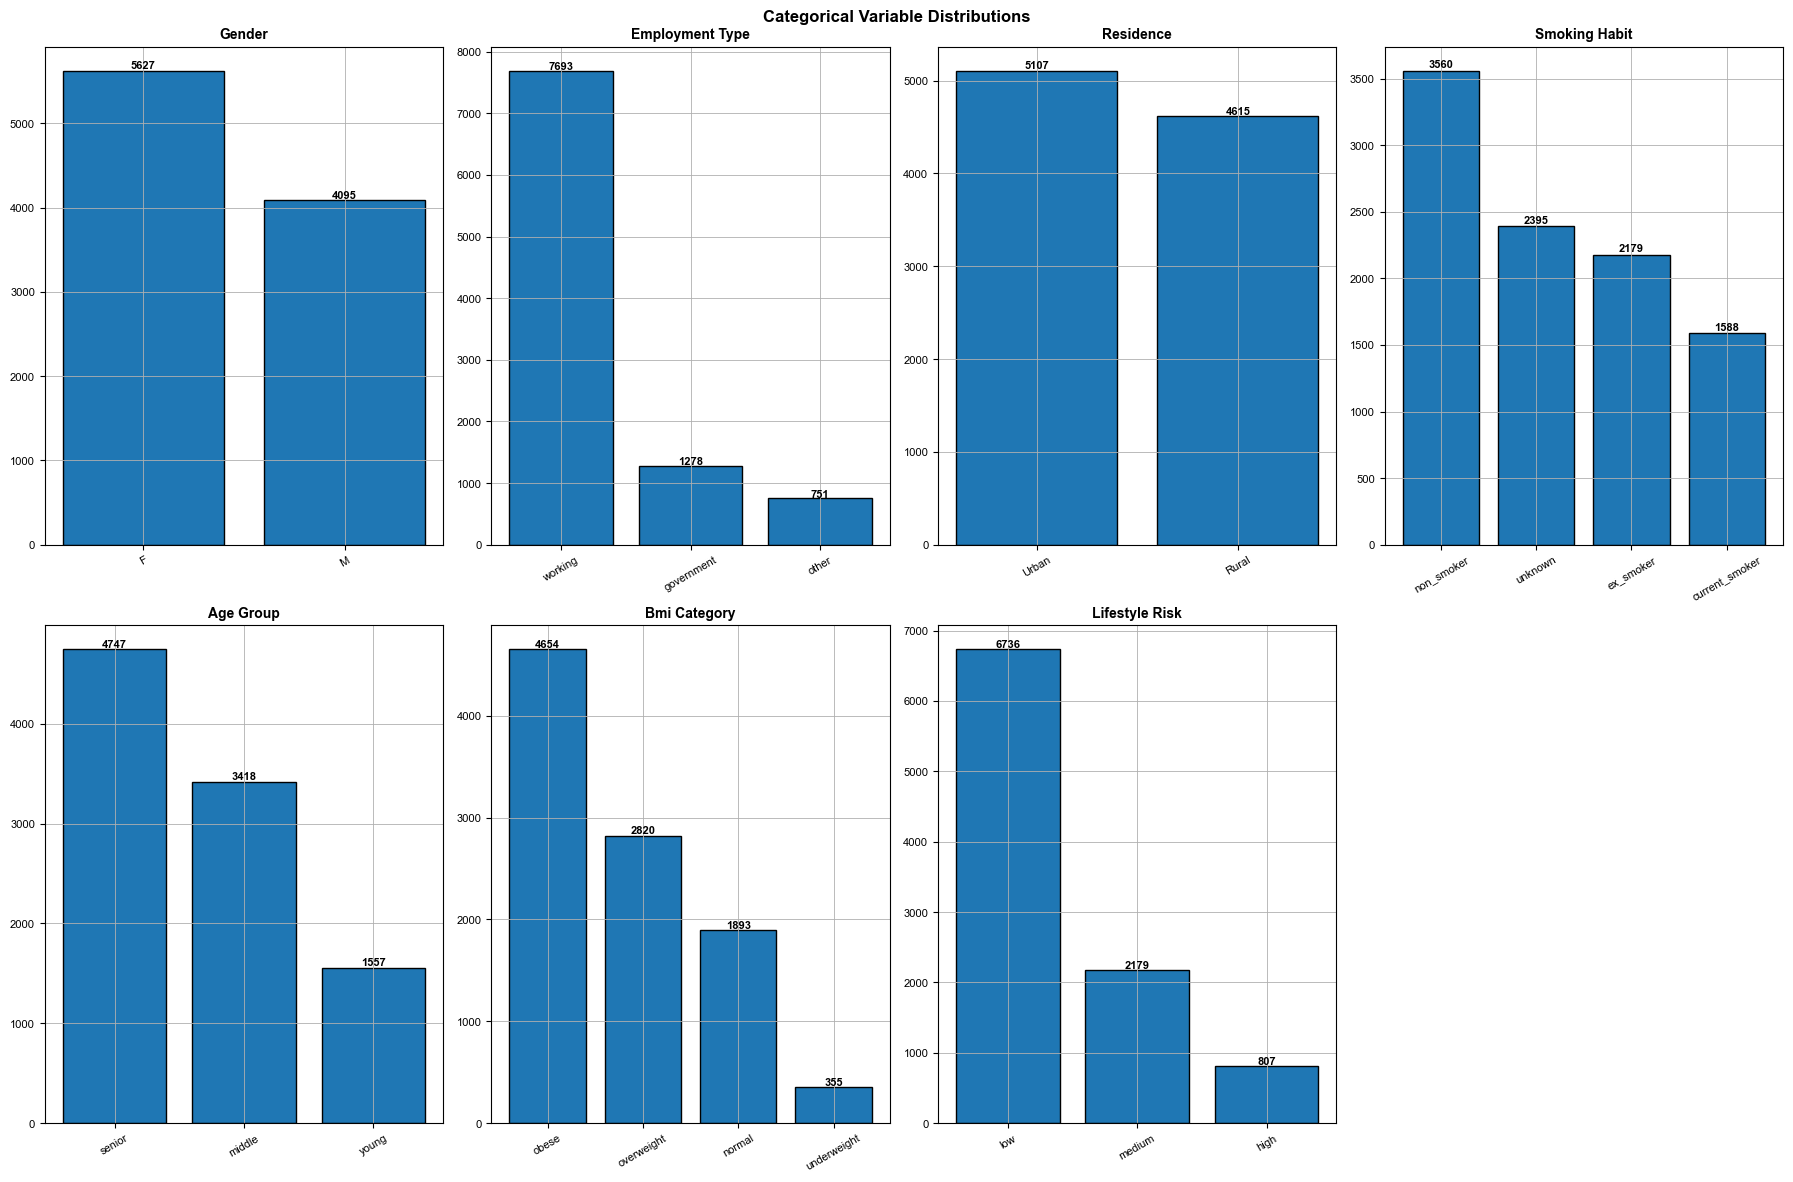

In [81]:
categorical_cols = ['gender', 'employment_type', 'residence', 'smoking_habit', 'age_group', 'bmi_category', 'lifestyle_risk']

fig, axes = plt.subplots(2, 4, figsize=(18,12 ))
fig.suptitle('Categorical Variable Distributions', fontsize=12,
             fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = data[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       edgecolor='black')
    for b, v in zip(bars, counts.values):
        axes[i].text(b.get_x() + b.get_width()/2, v + 20, str(v),
                     ha='center', fontsize=8, fontweight='bold')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("Figures/Categorical_Variable_Distribution.png")
plt.show()

### **Numerical Variable Distributions**

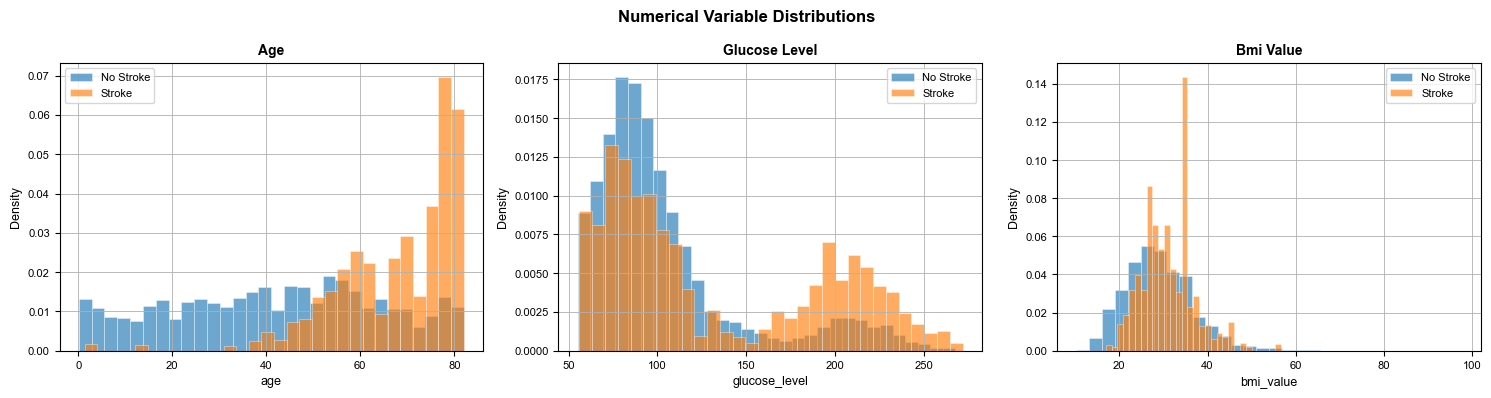

In [82]:
numerical_cols = ['age', 'glucose_level', 'bmi_value']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Numerical Variable Distributions', fontsize=12,
             fontweight='bold')

for ax, col in zip(axes, numerical_cols):
    for val, lbl in [(0,  'No Stroke'), (1, 'Stroke')]:
        ax.hist(data[data['stroke_event'] == val][col].dropna(),
                bins=30, alpha=0.65, label=lbl,
                density=True, edgecolor='white', linewidth=0.4)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig("Figures/Numerical_Variable_Distribution.png")
plt.show()

### **Demographic & Clinical Overview**

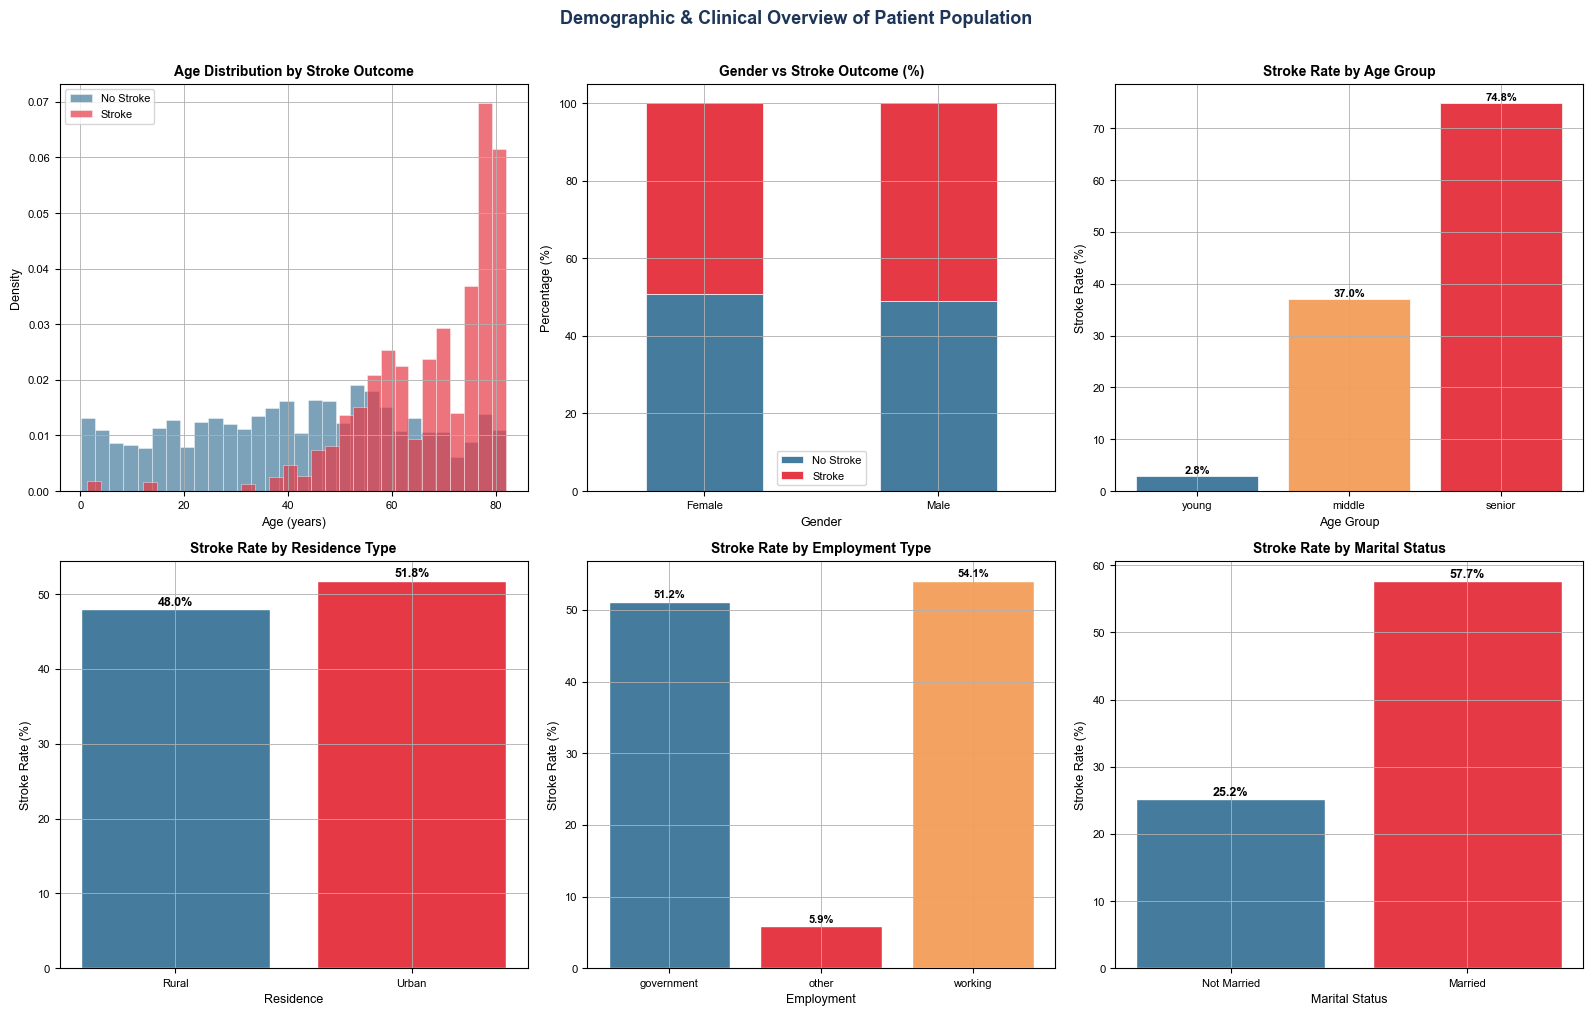

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Demographic & Clinical Overview of Patient Population',
             fontsize=13, fontweight='bold', color=DARK, y=1.01)
axes = axes.flatten()

# Age distribution by stroke
for value, color, label in [(0, NO_STROKE, 'No Stroke'), (1, STROKE, 'Stroke')]:
    axes[0].hist(data[data['stroke_event'] == value]['age'], bins=30, alpha=0.7,  color=color, label=label, density=True, edgecolor='white', linewidth=0.4)
axes[0].set(title='Age Distribution by Stroke Outcome', xlabel='Age (years)', ylabel='Density')
axes[0].legend()

# Gender vs Stroke stacked bar
gdf = data.groupby(['gender', 'stroke_event']).size().unstack(fill_value=0)
gdf_pct = gdf.div(gdf.sum(axis=1), axis=0) * 100
gdf_pct.plot(kind='bar', stacked=True, ax=axes[1], color=[NO_STROKE, STROKE], edgecolor='white', linewidth=0.5)
axes[1].set(title='Gender vs Stroke Outcome (%)', xlabel='Gender', ylabel='Percentage (%)')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['No Stroke', 'Stroke'])

# Age group stroke rate
ag_rate = data.groupby('age_group')['stroke_event'].mean() * 100
order = ['young', 'middle', 'senior']
bars = axes[2].bar(order, [ag_rate[o] for o in order], color=[NO_STROKE, ACCENT, STROKE], edgecolor='white', linewidth=0.5)
for b, v in zip(bars, [ag_rate[o] for o in order]):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[2].set(title='Stroke Rate by Age Group', xlabel='Age Group', ylabel='Stroke Rate (%)')

# Residence vs Stroke stacked
res_rate = data.groupby('residence')['stroke_event'].mean() * 100
bars2 = axes[3].bar(res_rate.index, res_rate.values, color=[NO_STROKE, STROKE], edgecolor='white')
for b, v in zip(bars2, res_rate.values):
    axes[3].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[3].set(title='Stroke Rate by Residence Type', xlabel='Residence', ylabel='Stroke Rate (%)')

# Employment type vs Stroke stacked
emp_rate = data.groupby('employment_type')['stroke_event'].mean() * 100
bars3 = axes[4].bar(emp_rate.index, emp_rate.values, color=[NO_STROKE, STROKE, ACCENT], edgecolor='white')
for b, v in zip(bars3, emp_rate.values):
    axes[4].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[4].set(title='Stroke Rate by Employment Type', xlabel='Employment', ylabel='Stroke Rate (%)')

# Marital status
mar = data.groupby('marital_status')['stroke_event'].mean() * 100
bars4 = axes[5].bar(['Not Married', 'Married'], mar.values, color=[NO_STROKE, STROKE], edgecolor='white')
for b, v in zip(bars4, mar.values):
    axes[5].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[5].set(title='Stroke Rate by Marital Status', xlabel='Marital Status', ylabel='Stroke Rate (%)')

plt.tight_layout()
plt.savefig("Figures/Demographic_&_Clinical_Overview_of_Patient_Population.png")
plt.show()


### **Clinical Measurements & Biomarker Analysis**

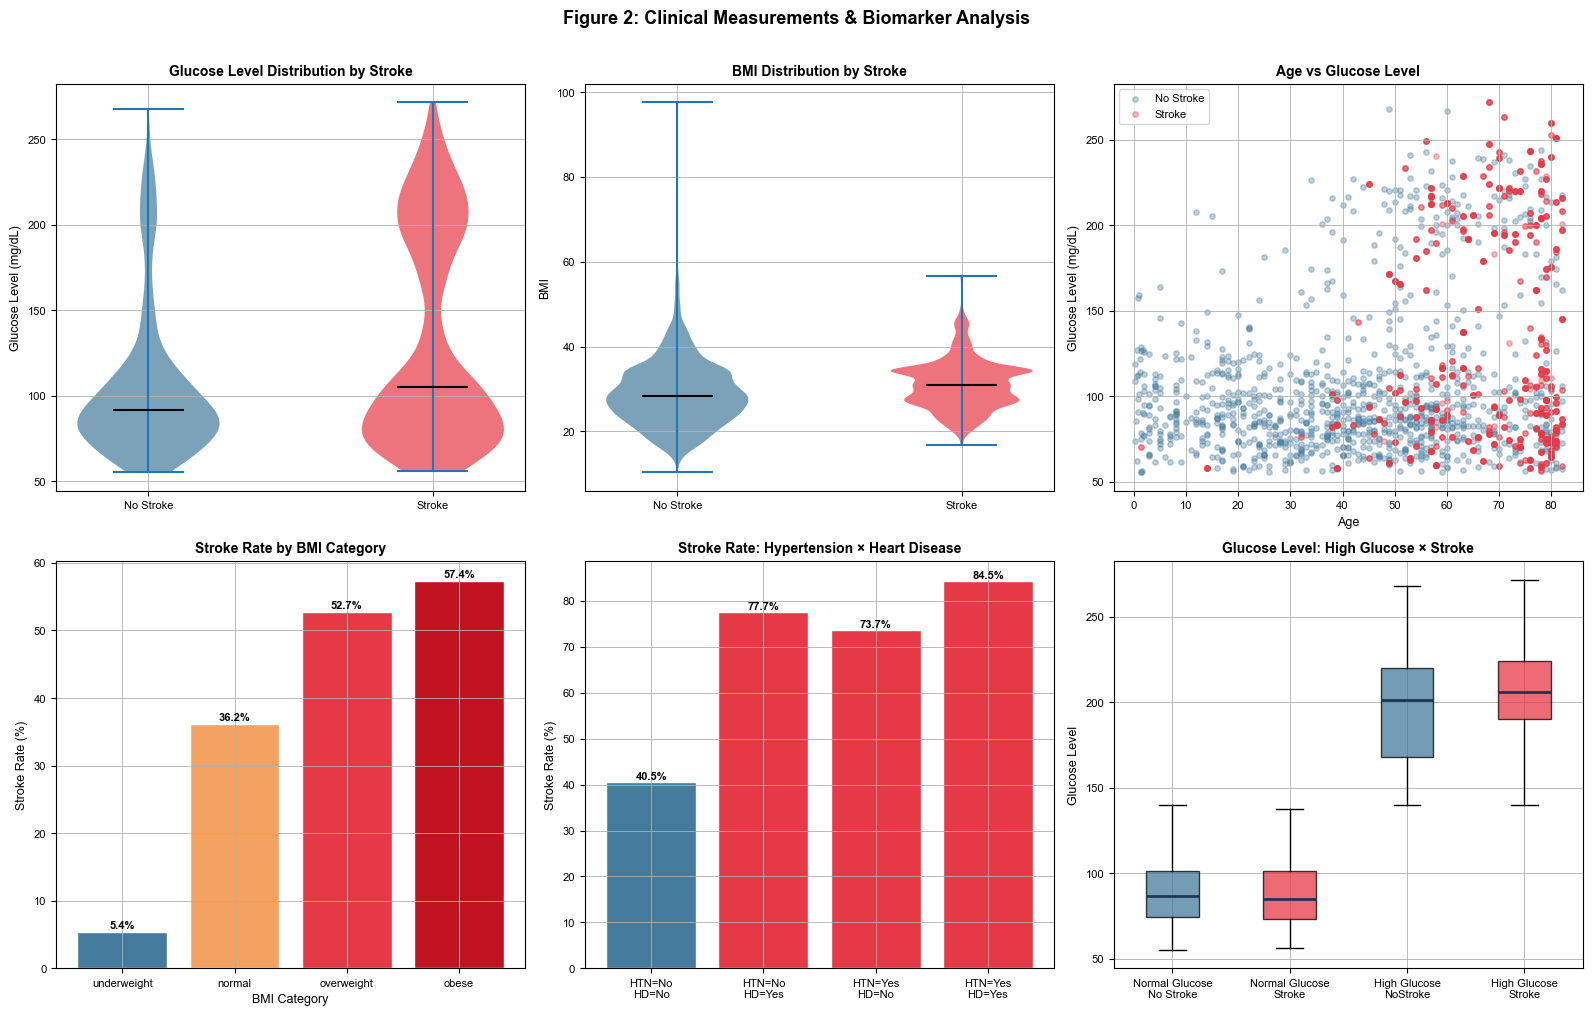

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 2: Clinical Measurements & Biomarker Analysis',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

# Glucose violin
parts = axes[0].violinplot([data[data['stroke_event'] == 0]['glucose_level'], data[data['stroke_event'] == 1]['glucose_level']], positions=[0, 1], showmedians=True)
for pc, col in zip(parts['bodies'], [NO_STROKE, STROKE]):
    pc.set_facecolor(col); pc.set_alpha(0.7)

parts['cmedians'].set_color("black")
axes[0].set(title='Glucose Level Distribution by Stroke', xticks=[0, 1], xticklabels=['No Stroke', 'Stroke'], ylabel='Glucose Level (mg/dL)')

parts2 = axes[1].violinplot([data[data['stroke_event'] == 0]['bmi_value'].dropna(), data[data['stroke_event'] == 1]['bmi_value'].dropna()], positions=[0, 1], showmedians=True)
for pc, col in zip(parts2['bodies'], [NO_STROKE, STROKE]):
    pc.set_facecolor(col); pc.set_alpha(0.7)

parts2['cmedians'].set_color("black")
axes[1].set(title='BMI Distribution by Stroke', xticks=[0, 1], xticklabels=['No Stroke', 'Stroke'], ylabel='BMI')

# Scatter: age vs glucose
sample = data.sample(2000, random_state=42)
for val, col, lbl in [(0, NO_STROKE, 'No Stroke'), (1, STROKE, 'Stroke')]:
    sub = sample[sample['stroke_event'] == val]
    axes[2].scatter(sub['age'], sub['glucose_level'], c=col, alpha=0.35, s=15, label=lbl)

axes[2].set(title='Age vs Glucose Level', xlabel='Age', ylabel='Glucose Level (mg/dL)')
axes[2].legend()

# BMI category stroke rate
bmi_order = ['underweight', 'normal', 'overweight', 'obese']
bmi_rate  = data.groupby('bmi_category')['stroke_event'].mean() * 100
bars5 = axes[3].bar(bmi_order, [bmi_rate[b] for b in bmi_order], color=[NO_STROKE, ACCENT, STROKE, '#C1121F'], edgecolor='white')

for b, v in zip(bars5, [bmi_rate[bm] for bm in bmi_order]):
    axes[3].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[3].set(title='Stroke Rate by BMI Category', xlabel='BMI Category', ylabel='Stroke Rate (%)')

# Hypertension × Heart Disease
comb = data.groupby(['has_hypertension', 'has_heart_disease'])['stroke_event'].mean().reset_index()
comb['label'] = comb.apply( lambda r: f"HTN={'Yes' if r.has_hypertension else 'No'}\nHD={'Yes' if r.has_heart_disease else 'No'}", axis=1)
colors_c = [NO_STROKE if v < 0.5 else STROKE for v in comb['stroke_event']]
bars6 = axes[4].bar(comb['label'], comb['stroke_event'] * 100, color=colors_c, edgecolor='white')
for b, v in zip(bars6, comb['stroke_event'] * 100):
    axes[4].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

axes[4].set(title='Stroke Rate: Hypertension × Heart Disease', ylabel='Stroke Rate (%)')

# High glucose × stroke boxplot
pivot = [
    data[(data['high_glucose'] == 0) & (data['stroke_event'] == 0)]['glucose_level'],
    data[(data['high_glucose'] == 0) & (data['stroke_event'] == 1)]['glucose_level'],
    data[(data['high_glucose'] == 1) & (data['stroke_event'] == 0)]['glucose_level'],
    data[(data['high_glucose'] == 1) & (data['stroke_event'] == 1)]['glucose_level'],
]
bp = axes[5].boxplot(pivot, patch_artist=True, medianprops=dict(color=DARK, linewidth=2))
for patch, col in zip(bp['boxes'], [NO_STROKE, STROKE, NO_STROKE, STROKE]):
    patch.set_facecolor(col); patch.set_alpha(0.75)

axes[5].set(title='Glucose Level: High Glucose × Stroke',ylabel='Glucose Level', xticklabels=['Normal Glucose\nNo Stroke', 'Normal Glucose\nStroke', 'High Glucose\nNoStroke', 'High Glucose\nStroke'])

plt.tight_layout()
plt.savefig("Figures/Clinical_Measurements_&_Biomarker_Analysis.png")
plt.show()

#### **Lifestyle Risk Factors**

C:\Users\user\AppData\Local\Temp\ipykernel_6264\3169314052.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non\nSmoker', 'Ex\nSmoker', 'Current\nSmoker', 'Unknown'])


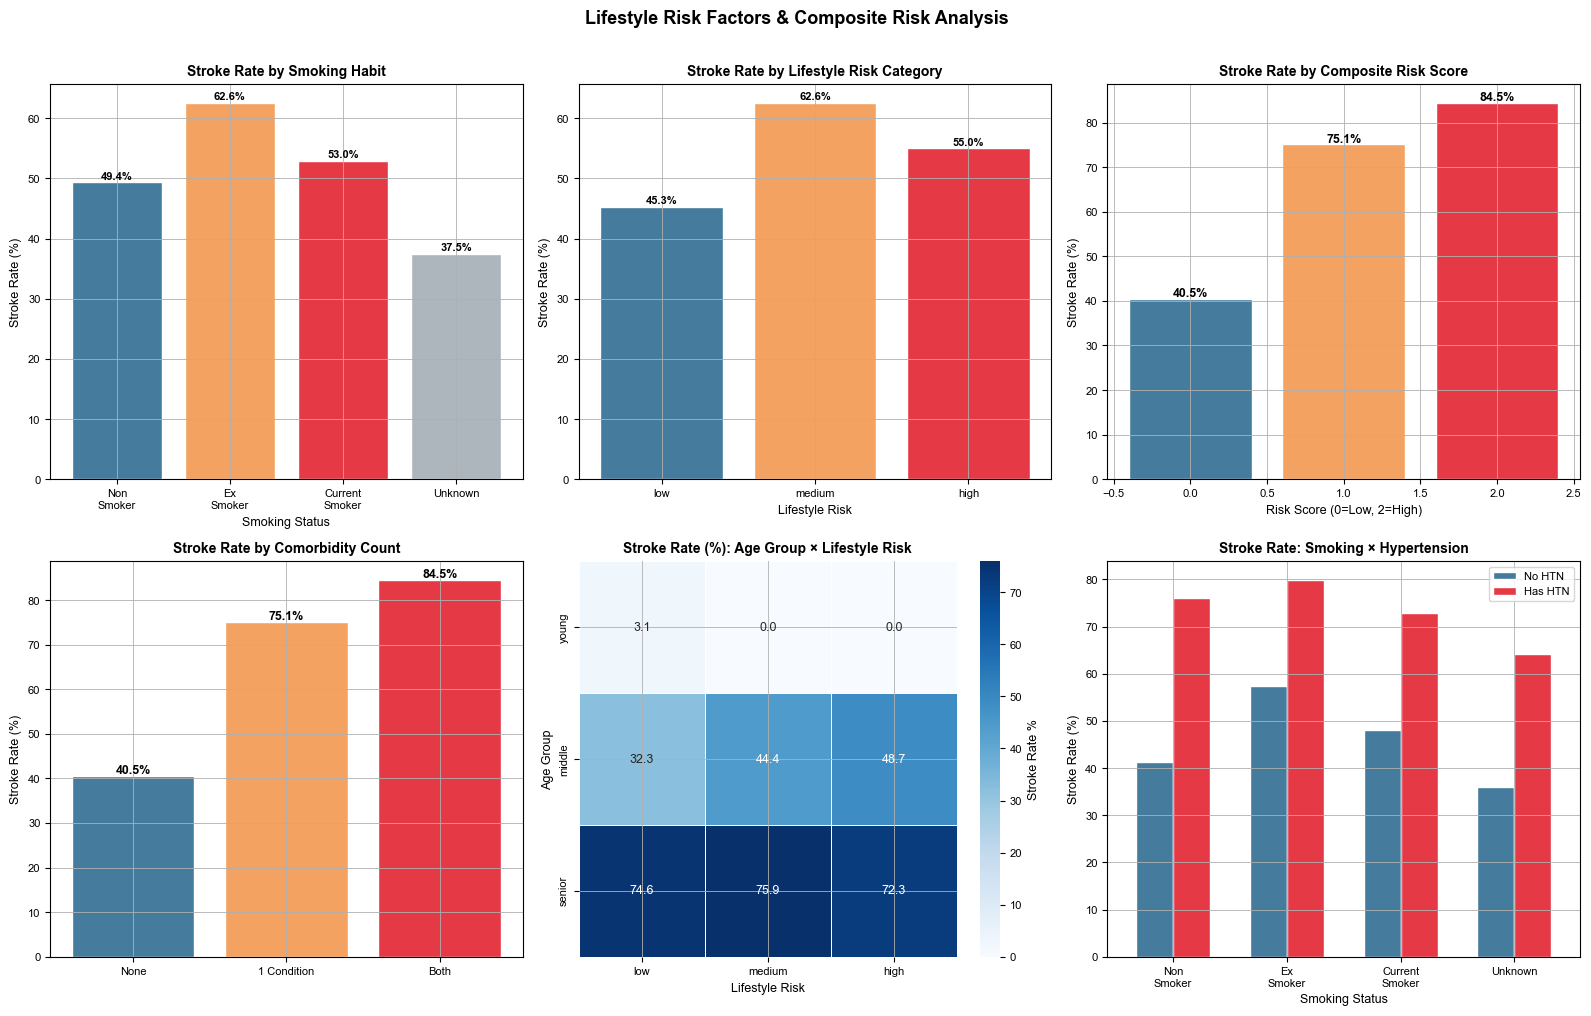

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Lifestyle Risk Factors & Composite Risk Analysis',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

# Smoking habit
smk_rate  = data.groupby('smoking_habit')['stroke_event'].mean() * 100
smk_order = ['non_smoker', 'ex_smoker', 'current_smoker', 'unknown']
bars7 = axes[0].bar(smk_order, [smk_rate[s] for s in smk_order],color=[NO_STROKE, ACCENT, STROKE, '#ADB5BD'], edgecolor='white')
for b, v in zip(bars7, [smk_rate[s] for s in smk_order]):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[0].set(title='Stroke Rate by Smoking Habit', xlabel='Smoking Status', ylabel='Stroke Rate (%)')
axes[0].set_xticklabels(['Non\nSmoker', 'Ex\nSmoker', 'Current\nSmoker', 'Unknown'])

# Lifestyle risk
lr_rate  = data.groupby('lifestyle_risk')['stroke_event'].mean() * 100
lr_order = ['low', 'medium', 'high']
bars8 = axes[1].bar(lr_order, [lr_rate[l] for l in lr_order], color=[NO_STROKE, ACCENT, STROKE], edgecolor='white')
for b, v in zip(bars8, [lr_rate[l] for l in lr_order]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[1].set(title='Stroke Rate by Lifestyle Risk Category', xlabel='Lifestyle Risk', ylabel='Stroke Rate (%)')

# Risk score
rs_rate = data.groupby('risk_score')['stroke_event'].mean() * 100
axes[2].bar(rs_rate.index, rs_rate.values, color=[NO_STROKE, ACCENT, STROKE], edgecolor='white')
for s, v in rs_rate.items():
    axes[2].text(s, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set(title='Stroke Rate by Composite Risk Score', xlabel='Risk Score (0=Low, 2=High)', ylabel='Stroke Rate (%)')

# Comorbidity
co_rate = data.groupby('comorbidity')['stroke_event'].mean() * 100
axes[3].bar(['None', '1 Condition', 'Both'], co_rate.values, color=[NO_STROKE, ACCENT, STROKE], edgecolor='white')
for i, v in enumerate(co_rate.values):
    axes[3].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[3].set(title='Stroke Rate by Comorbidity Count', ylabel='Stroke Rate (%)')

# Heatmap: age group × lifestyle risk
heat = (data.groupby(['age_group', 'lifestyle_risk'])['stroke_event'].mean().unstack() * 100)
heat = heat.reindex(['young', 'middle', 'senior'])[['low', 'medium', 'high']]
sns.heatmap(heat, ax=axes[4], annot=True, fmt='.1f',cmap='Blues', linewidths=0.5,cbar_kws={'label': 'Stroke Rate %'})
axes[4].set(title='Stroke Rate (%): Age Group × Lifestyle Risk',xlabel='Lifestyle Risk', ylabel='Age Group')

# Smoking × hypertension
smk_htn = (data.groupby(['smoking_habit', 'has_hypertension'])['stroke_event'].mean().unstack() * 100)
smk_htn = smk_htn.reindex(['non_smoker', 'ex_smoker', 'current_smoker', 'unknown'])
smk_htn.columns = ['No HTN', 'Has HTN']
smk_htn.plot(kind='bar', ax=axes[5], color=[NO_STROKE, STROKE],edgecolor='white', width=0.65)
axes[5].set(title='Stroke Rate: Smoking × Hypertension',xlabel='Smoking Status', ylabel='Stroke Rate (%)')
axes[5].set_xticklabels(['Non\nSmoker', 'Ex\nSmoker','Current\nSmoker', 'Unknown'], rotation=0)

plt.tight_layout()
plt.savefig("Figures/Lifestyle_Risk_Factors_&_Composite_Risk_Analysis.png")
plt.show()


### **Statistical Tests & Correlation Analysis**

In [86]:
data.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk,age_bmi,glucose_age,comorbidity
0,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low,54.0,285.36,0
1,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low,2273.6,5101.68,1
2,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low,140.8,887.12,0
3,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium,2513.0,4832.80,0
4,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low,267.4,2257.92,0


Point-biserial correlations:
     Variable  Correlation       p_value
    bmi_value     0.147849  1.221336e-48
glucose_level     0.256178 1.688898e-145
   risk_score     0.308860 6.458801e-214
  glucose_age     0.469928  0.000000e+00
      age_bmi     0.533800  0.000000e+00
          age     0.579175  0.000000e+00
Chi-square results:
         Variable    Chi2  p_value  Cramér's V
        age_group 2786.98  0.00000      0.5354
   marital_status  745.95  0.00000      0.2770
     high_glucose  681.79  0.00000      0.2648
  employment_type  638.10  0.00000      0.2562
 has_hypertension  572.75  0.00000      0.2427
     bmi_category  537.46  0.00000      0.2351
has_heart_disease  445.87  0.00000      0.2142
    smoking_habit  294.24  0.00000      0.1740
   lifestyle_risk  205.37  0.00000      0.1453
        residence   13.97  0.00019      0.0379
           gender    2.70  0.10033      0.0167


C:\Users\user\AppData\Local\Temp\ipykernel_6264\2620948146.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[4].boxplot(groups, labels=['Young', 'Middle', 'Senior'],


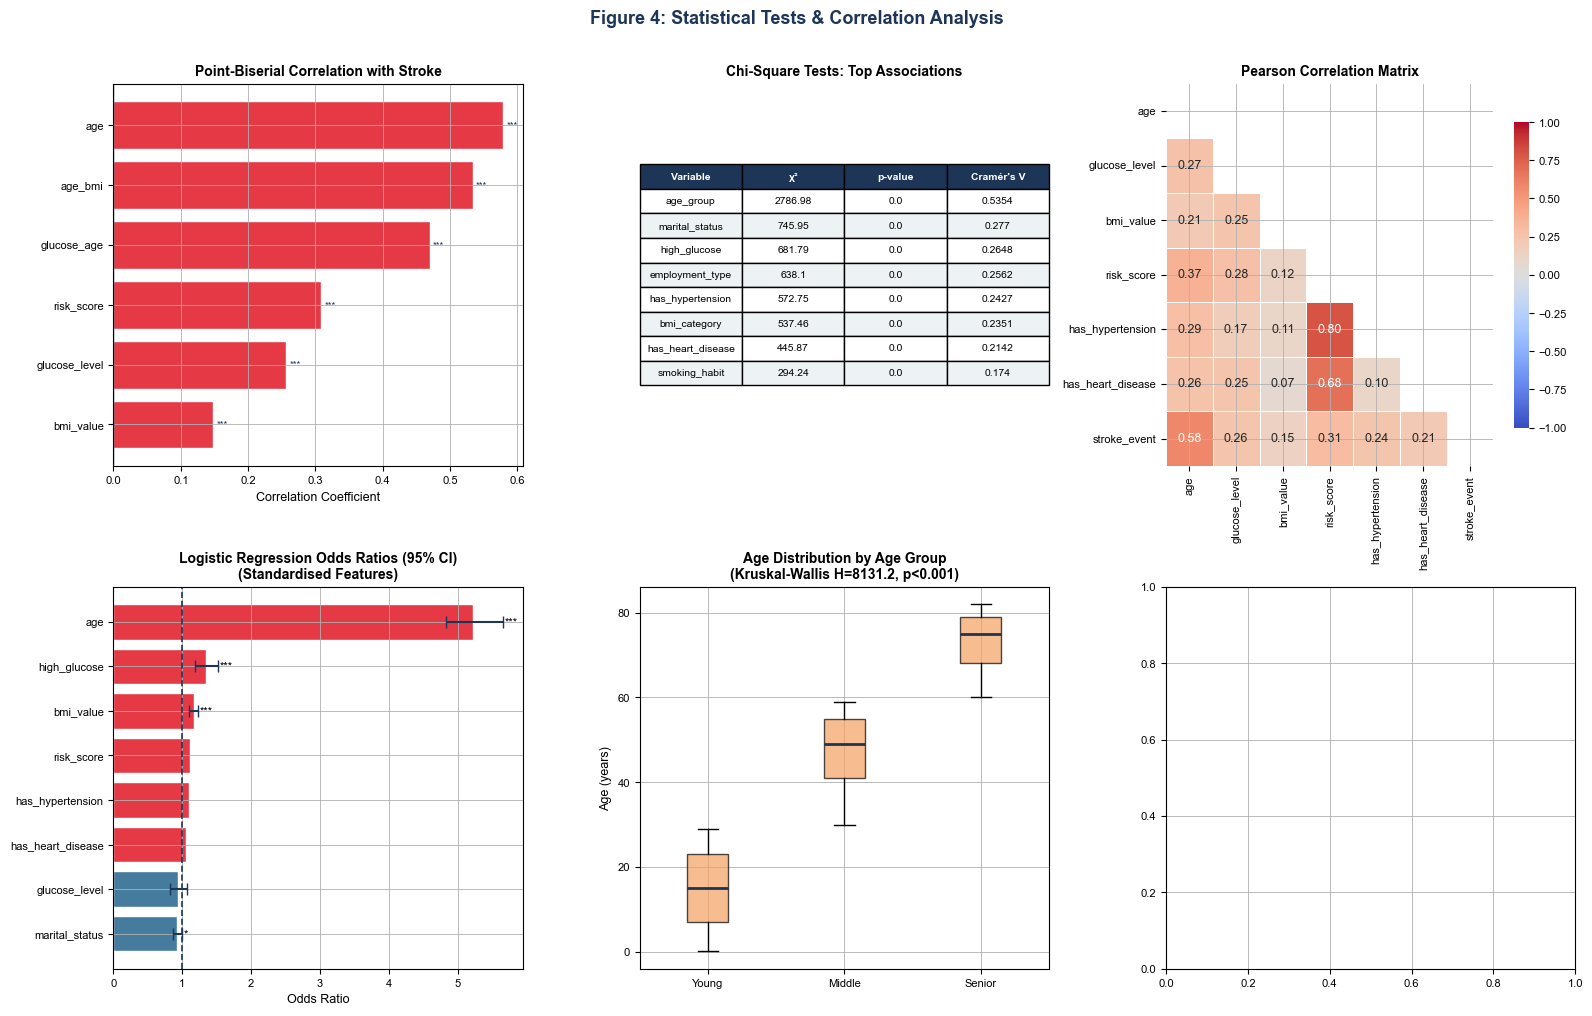

Kruskal-Wallis: H=8131.19, p=0.000000


<Figure size 640x480 with 0 Axes>

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 4: Statistical Tests & Correlation Analysis',
             fontsize=13, fontweight='bold', color=DARK, y=1.01)
axes = axes.flatten()

# Point-biserial correlations
num_cols = ['age', 'glucose_level', 'bmi_value',
            'risk_score', 'age_bmi', 'glucose_age']
corrs, pvals = [], []
for c in num_cols:
    d = data[['stroke_event', c]].dropna()
    r, p = pointbiserialr(d['stroke_event'], d[c])
    corrs.append(r); pvals.append(p)

corr_df = pd.DataFrame({'Variable': num_cols, 'Correlation': corrs, 'p_value': pvals})
corr_df = corr_df.sort_values('Correlation', ascending=True)
colors_corr = [STROKE if v > 0 else NO_STROKE for v in corr_df['Correlation']]
axes[0].barh(corr_df['Variable'], corr_df['Correlation'], color=colors_corr, edgecolor='white')
axes[0].axvline(0, color=DARK, linewidth=1)
axes[0].set(title='Point-Biserial Correlation with Stroke', xlabel='Correlation Coefficient')
for i, (v, p) in enumerate(zip(corr_df['Correlation'], corr_df['p_value'])):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    axes[0].text(v + 0.005 if v > 0 else v - 0.005, i, sig, va='center', fontsize=7, color=DARK)

print("Point-biserial correlations:")
print(corr_df.to_string(index=False))

cat_cols_chi = ['gender', 'employment_type', 'residence', 'smoking_habit',
                'age_group', 'bmi_category', 'lifestyle_risk',
                'has_hypertension', 'has_heart_disease',
                'marital_status', 'high_glucose']
chi2_results = []
for col in cat_cols_chi:
    ct = pd.crosstab(data[col], data['stroke_event'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = len(data)
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({'Variable': col, 'Chi2': round(chi2, 2),
                         'p_value': round(p, 5),
                         "Cramér's V": round(cramers_v, 4)})

chi_df = pd.DataFrame(chi2_results).sort_values("Cramér's V", ascending=False)
print("Chi-square results:")
print(chi_df.to_string(index=False))

# Pearson correlation matrix
num_feat = ['age', 'glucose_level', 'bmi_value', 'risk_score',
            'has_hypertension', 'has_heart_disease', 'stroke_event']
corr_mat = data[num_feat].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=axes[2], mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[2].set_title('Pearson Correlation Matrix', fontweight='bold')

# Logistic regression odds ratios
le = LabelEncoder()
df_enc = data.copy()
for col in ['gender', 'employment_type', 'residence', 'smoking_habit',
            'age_group', 'bmi_category', 'lifestyle_risk']:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

features = ['age', 'glucose_level', 'bmi_value', 'has_hypertension',
            'has_heart_disease', 'marital_status', 'risk_score', 'high_glucose']
X_lr = df_enc[features].fillna(df_enc[features].median())
y_lr = df_enc['stroke_event']
scaler = StandardScaler()
X_sc  = scaler.fit_transform(X_lr)

lr_sm = sm.Logit(y_lr, sm.add_constant(X_sc)).fit(disp=False)
OR    = np.exp(lr_sm.params[1:])
conf  = lr_sm.conf_int()[1:]
OR_lo = np.exp(conf[0])
OR_hi = np.exp(conf[1])
pvals_lr = lr_sm.pvalues[1:]

or_df = pd.DataFrame({'Feature': features, 'OR': OR,
                      'Lower': OR_lo, 'Upper': OR_hi, 'p': pvals_lr})
or_df = or_df.sort_values('OR')

axes[3].barh(or_df['Feature'], or_df['OR'],
             xerr=[or_df['OR'] - or_df['Lower'], or_df['Upper'] - or_df['OR']],
             color=[STROKE if v > 1 else NO_STROKE for v in or_df['OR']],
             ecolor=DARK, capsize=4, edgecolor='white')
axes[3].axvline(1, color=DARK, linestyle='--', linewidth=1.2)
axes[3].set(title='Logistic Regression Odds Ratios (95% CI)\n(Standardised Features)',
            xlabel='Odds Ratio')
for i, (_, row) in enumerate(or_df.iterrows()):
    sig = '***' if row.p < 0.001 else ('**' if row.p < 0.01 else ('*' if row.p < 0.05 else ''))
    axes[3].text(row['Upper'] + 0.02, i, sig, va='center', fontsize=8)

# Kruskal-Wallis test for age by age group
groups = [data[data['age_group'] == g]['age'] for g in ['young', 'middle', 'senior']]
kw_stat, kw_p = kruskal(*groups)
axes[4].boxplot(groups, labels=['Young', 'Middle', 'Senior'],
                patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.7),
                medianprops=dict(color=DARK, linewidth=2))
axes[4].set(title=f'Age Distribution by Age Group\n(Kruskal-Wallis H={kw_stat:.1f}, p<0.001)',
            ylabel='Age (years)')

# Display the chi-square table in axis 1
axes[1].axis('off')
top_chi = chi_df.head(8)
tbl = axes[1].table(
    cellText=top_chi[["Variable", "Chi2", "p_value", "Cramér's V"]].values,
    colLabels=["Variable", "χ²", "p-value", "Cramér's V"],
    cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
tbl.scale(1, 1.35)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(DARK); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EDF2F4')
axes[1].set_title("Chi-Square Tests: Top Associations", fontweight='bold', pad=6)

plt.tight_layout()
plt.show()
print(f"Kruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.6f}")
plt.savefig("Figures/Statistical_Tests_&_Correlation_Analysis.png")



### **Predictive Model Development & Evaluation**

In [88]:
all_features = ['age', 'glucose_level', 'bmi_value', 'has_hypertension',
                'has_heart_disease', 'marital_status', 'risk_score',
                'high_glucose', 'comorbidity', 'age_bmi', 'glucose_age']

X = df_enc[all_features].fillna(df_enc[all_features].median())
y = df_enc['stroke_event']
X_sc_all = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_sc_all, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Positive rate — Train: {y_train.mean():.3f}  Test: {y_test.mean():.3f}")

Train: (7777, 11)  |  Test: (1945, 11)
Positive rate — Train: 0.500  Test: 0.500


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
skf = StratifiedKFold(n_splits=5)
for name, mdl in models.items():
    print(f"Training {name}...")
    mdl.fit(X_train, y_train)
    y_prob = mdl.predict_proba(X_test)[:, 1]
    y_pred = mdl.predict(X_test)
    cv_auc = cross_val_score(mdl, X_sc_all, y, cv=skf,
                             scoring='roc_auc', n_jobs=-1).mean()
    results[name] = {
        'model': mdl, 'prob': y_prob, 'pred': y_pred,
        'auc':       roc_auc_score(y_test, y_prob),
        'cv_auc':    cv_auc,
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
    }
    print(f"  AUC={results[name]['auc']:.4f}  CV-AUC={cv_auc:.4f}  F1={results[name]['f1']:.4f} \n")


Training Logistic Regression...
  AUC=0.8539  CV-AUC=0.8470  F1=0.7801 

Training Random Forest...
  AUC=1.0000  CV-AUC=1.0000  F1=0.9883 

Training Gradient Boosting...


Best model: Random Forest


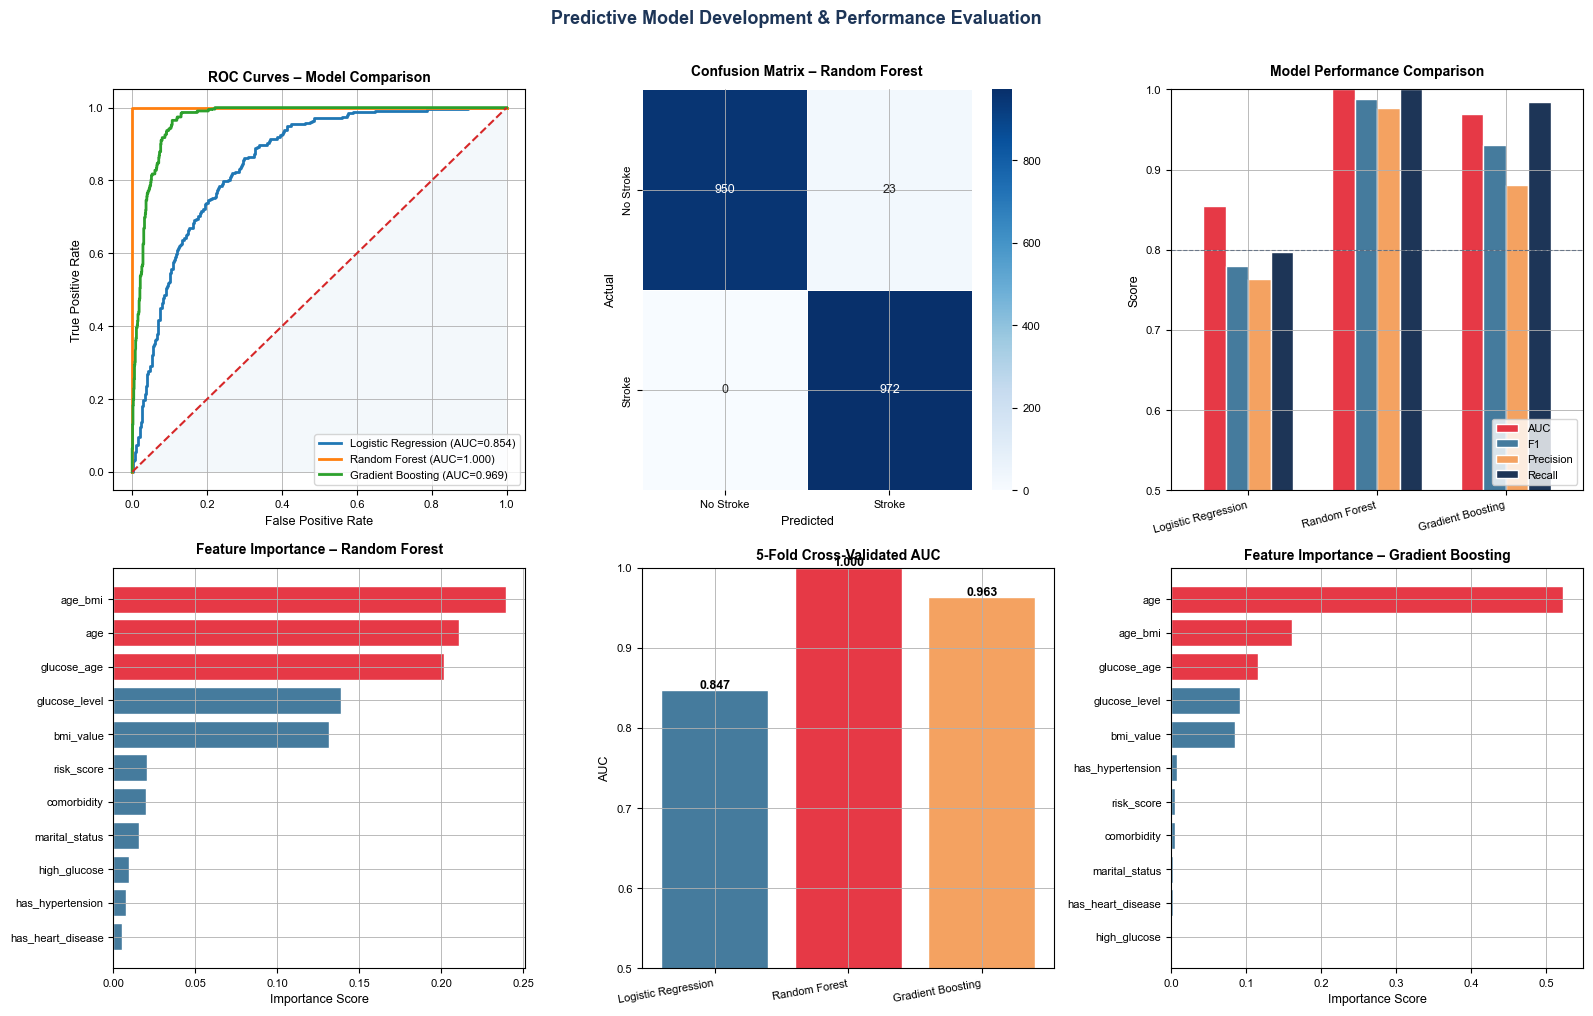

In [ ]:
best_name = max(results, key=lambda k: results[k]['auc'])
print(f"Best model: {best_name}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Predictive Model Development & Performance Evaluation', fontsize=13, fontweight='bold', color=DARK, y=1.01)
axes = axes.flatten()

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[0].plot(fpr, tpr,
                 label=f"{name} (AUC={res['auc']:.3f})", linewidth=2)
    
axes[0].plot([0, 1], [0, 1], '--')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05)
axes[0].set(title='ROC Curves – Model Comparison', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend(loc='lower right')

# Confusion matrix – best model
cm = confusion_matrix(y_test, results[best_name]['pred'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'], linewidths=0.5)
axes[1].set(xlabel='Predicted', ylabel='Actual')
axes[1].set_title(f'Confusion Matrix – {best_name}', pad=10) # Fixed pad error

# Model comparison
metrics_compare = pd.DataFrame({
    name: {'AUC': res['auc'], 
           'F1': res['f1'],
           'Precision': res['precision'], 
           'Recall': res['recall']}
    for name, res in results.items()
}).T

metrics_compare.plot(kind='bar', ax=axes[2], color=[STROKE, NO_STROKE, ACCENT, DARK], edgecolor='white', width=0.7)
axes[2].set(ylabel='Score', ylim=[0.5, 1.0])
axes[2].set_title('Model Performance Comparison', pad=10) # Fixed pad error
axes[2].set_xticks(range(len(metrics_compare.index))) # Fixed tick warning
axes[2].set_xticklabels(metrics_compare.index, rotation=15, ha='right')
axes[2].legend(loc='lower right')
axes[2].axhline(0.8, color=DARK, linestyle='--', linewidth=0.8, alpha=0.5)

# Feature importance – Random Forest
rf = results['Random Forest']['model']
feat_imp = pd.DataFrame({'Feature': all_features,'Importance': rf.feature_importances_}).sort_values('Importance')
colors_fi = [STROKE if i >= len(feat_imp) - 3 else NO_STROKE
             for i in range(len(feat_imp))]

axes[3].barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_fi, edgecolor='white')
axes[3].set(xlabel='Importance Score')
axes[3].set_title('Feature Importance – Random Forest', pad=10) # Fixed pad error

# CV AUC comparison
cv_names = list(results.keys())
cv_vals  = [results[n]['cv_auc'] for n in cv_names]
bars_cv  = axes[4].bar(cv_names, cv_vals, color=[NO_STROKE, STROKE, ACCENT], edgecolor='white')
for b, v in zip(bars_cv, cv_vals):
    axes[4].text(b.get_x() + b.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

axes[4].set(title='5-Fold Cross-Validated AUC', ylabel='AUC', ylim=[0.5, 1.0])
axes[4].set_xticks(range(len(cv_names))) # Fixed tick warning
axes[4].set_xticklabels(cv_names, rotation=10, ha='right')

# Gradient Boosting feature importance
gb = results['Gradient Boosting']['model']
gb_imp = pd.DataFrame({'Feature': all_features, 'Importance': gb.feature_importances_}).sort_values('Importance')
colors_gb = [STROKE if i >= len(gb_imp) - 3 else NO_STROKE for i in range(len(gb_imp))]
axes[5].barh(gb_imp['Feature'], gb_imp['Importance'], color=colors_gb, edgecolor='white')
axes[5].set(title='Feature Importance – Gradient Boosting', xlabel='Importance Score')

plt.tight_layout()
plt.savefig("Figures/Predictive_Model_Development_&_Performance_Evaluation.png")
plt.show()

In [ ]:
print(f"=== Classification Report: {best_name} ===")
print(classification_report(y_test, results[best_name]['pred'],target_names=['No Stroke', 'Stroke']))

=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

   No Stroke       1.00      0.98      0.99       973
      Stroke       0.98      1.00      0.99       972

    accuracy                           0.99      1945
   macro avg       0.99      0.99      0.99      1945
weighted avg       0.99      0.99      0.99      1945

